# Ridewise-Churn Modeling & Evaluation
- purpose: train another model to predict which rider will churn, evaluated their performance and select the best

- we have like 10,000 riders, about 10% will churn next month, which ones?
- solution : Train a model that scores each rider 0-100% churnprobability
- High score (80% +) Urgent intervention
- Medium score (40-80%) monitor closely
- Low score (<40%) stable, maintain quality service



- Logistic regression (simple,fast, interpretble)-- Baseline model
- random forest classifier --- more robust, can handle non-linear relationship
- Xgboost ---- often best perfomance(advance model)-- handle imbalance dataset

Step 1 Setp and Load data

In [111]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.2)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# import our evaluation library
from sklearn.metrics import (
    roc_auc_score,f1_score, precision_score, recall_score,
    RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix, precision_recall_curve
)
from xgboost import XGBClassifier


# define our system location
# define the data paths
DATA_PROCESSED = os.path.join("..", "data", "processed")
MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

features = pd.read_csv(os.path.join(DATA_PROCESSED, "features.csv")) 
segment_df = pd.read_csv(os.path.join(DATA_PROCESSED, "segment_assignment.csv"))

Step 2 - Prepare our Data

In [112]:
df = features
df.head()

,user_id,churned,days_since_last_trip,days_since_last_session,trips_last_7d,trips_last_30d,trips_last_60d,trips_last_90d,monetary_total,monetary_avg,...,avg_pages_visited,session_conversation_rate,engagement_score,account_age_days,activity_trend_30d,unique_active_days,was_referred,avg_rating_given,loyalty_encoded,city_encoded
0,R00000,0,25,0.0,0,1,1,3,414.13,16.57,...,3.00,0.25,276.00,93,0.50,25,1,5.0,0,0
1,R00001,1,5,0.0,1,2,3,3,195.69,13.98,...,2.67,0.00,466.37,230,0.67,13,0,4.7,0,0
2,R00002,1,14,0.0,0,1,4,5,482.94,20.12,...,3.00,0.00,573.00,232,0.50,22,0,4.2,0,1
3,R00004,0,12,0.0,0,2,2,5,391.15,24.45,...,2.50,0.00,42.50,250,0.67,16,1,3.9,1,1
4,R00005,0,2,0.0,1,2,2,4,300.63,15.82,...,1.67,0.17,50.65,657,0.67,19,0,5.0,0,1


In [113]:
# Drop the churn columns
# The reason we have to drop the churned column its becasue we cannot train a model without knowing the true label

df = features.dropna(subset=["churned"]).copy()
chuned_rate = df["churned"].mean()
print(f"Riders : {len(df):,}")  
print(f"Churned: {df['churned'].sum():,} ({chuned_rate * 100: 1f}%)")  

Riders : 9,204
Churned: 989 ( 10.745328%)


In [114]:
# 10% churned is slightly imbalanced but manageable
# <5%r >40%
# we use class_weight="balanced"

### stop 2 - Features & Train/test split

In [115]:
# Step 2a:
# user_id : identifier are not a pattern
# Churned : Target label ( can use the answer to predict itself)
EXCLUDE = ["user_id", "churned"]


# All other 36 features will be kept
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

print(f"{len(FEATURE_COLS)} features selected")
print(FEATURE_COLS)

36 features selected
['days_since_last_trip', 'days_since_last_session', 'trips_last_7d', 'trips_last_30d', 'trips_last_60d', 'trips_last_90d', 'monetary_total', 'monetary_avg', 'trips_lifetime', 'monetary_last_30d', 'rfm_recency_score', 'rfm_frequency_score', 'rfm_monetary_score', 'rfm_combined_score', 'avg_trip_duration', 'avg_fare', 'avg_surge', 'tip_rate', 'peak_hour_rate', 'weekend_ratio', 'rainy_ride_ratio', 'preferred_payment_encoded', 'avg_driver_rating_received', 'session_last_30d', 'session_last_60d', 'avg_time_on_app', 'avg_pages_visited', 'session_conversation_rate', 'engagement_score', 'account_age_days', 'activity_trend_30d', 'unique_active_days', 'was_referred', 'avg_rating_given', 'loyalty_encoded', 'city_encoded']


In [116]:
# Step 2b:
# Lets prepare an array of data 
# we would need X and y

X = df[FEATURE_COLS].values
y = df["churned"].values

# Lets check the shape of these dataset
print(X.shape)
print(y.shape)


(9204, 36)
(9204,)


In [117]:
# Step 2c : Train/ Test and Split

# Test_size = 0.2, that is 20%
# 80% training data  (8000 riders)
# 20% testing data (2000 riders)

# random_state = 42
# this means that everybody will get a split
# Any number can work it must not be only 42

# When we talk about stratify 
# y = target variable == churn rate
# ensure the train and test have the same churn rate
# without stratify : train 12% churn, test 8% === biased evaluation

# scale_pos_weight
# ration of negative (active) to positive (churned) example,
# used by Xgboost to handle class imbalace
# formular = neg/pos -- 7152/848 == 8.4 
# tells model "churned riders are 8.4x rarer, weigh them 8.4x more"

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# sacle positive weight
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg/pos 

print(f"Train: {len(X_train):,}  Test:{len(X_test):,} | Scale_pos_weight: {scale_pos:.1f}")

Train: 7,363  Test:1,841 | Scale_pos_weight: 8.3


### Step 2b - Logistic Regression

In [118]:
# understand the 3 models

# model : Logistic regression (Baseline)

# image plotting riders on a graph
# X = RF combined score
# Y = churn probability

# give more weight/coeficient to churned examples during training
# formular = weight = n_samples/(n_classes * class_count)

# max_iter =500 : maximum iteration for optimization
# default is 100, sometimes is not enough (converge)

lr = LogisticRegression(class_weight="balanced", max_iter=500, random_state=42)

### Step 2c - Random Forest

In [119]:
# random Forest (ensenble method -- collection of decision trees)
# imagine 200 experts , each looking at random subset of our features

# n_estimators=200: build 200 decision tree
# max_depth = Each tree can be max 10 levels deep
# prevent overfitting  (top deep = memorize the training data)
# n-jobs = -1 : use all CPU core for paralle training (faster) 
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1
)

### Step 2d - XGBOOST

In [120]:
# XGBOOST
# iterative Learner(self correct itself)
# Start with a model thats dumb, predicts everyone's churn probability = 10% (average)

# Round 1
# finds riders where model is mostly got it wrong
# builds a small tree to fix those mistakes
# updates the prediction slight.

# Round 2
# check: whos still predicted wrongly
# builds another small tree to fix those mistakes
# updates the predictions again

# repeats 200 times --- final model = sum of all the 200 trees 

# n_estimators = build 200 bossting rounds(trees)
# max_depth=5 : shallower trees than random forest
# XGBOOST  use many small trees: random forest use fewer large trees
# learning_rate=0.05 : how much each tree contributes
# lower -- more conservative, might generalize the training
# slow the training (more trees)
# scale pos weight == handle imbalance
# eva_metrics : optimization metric (log loss for)


xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos, eval_metric="logloss", use_label_encoder=False,
    random_state=42, n_jobs=-1
)

### Step 2e - Training Process

In [121]:
MODELS = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

probas, preds = {}, {}
for name, model in MODELS.items():  
    model.fit(X_train, y_train)
    probas[name] = model.predict_proba(X_test)[:, 1]  # probability of being in the positive class (churned)
    preds[name] = model.predict(X_test)  # predicted class labels (0 or 1)
    

    print(
        f"{name:25s} AUC: {roc_auc_score(y_test, probas[name]):.4f}"
        f" | F1: {f1_score(y_test, preds[name]):.4f}" )

Logistic Regression       AUC: 0.4700 | F1: 0.1660
Random Forest             AUC: 0.4756 | F1: 0.0000
XGBoost                   AUC: 0.4667 | F1: 0.1151


### STEP 2f - ROC & Precission - Recal Curves

- ROC is another form of evaluation matrix
- Matric ROC-AUC- (means Reciever Operating Characteristics-----------Area Uner CURVE)
- What does it measure : it has the ability to seperate all the classed across all threshold

### AUC - ROC

- Security scan at the Airport wants to scan you for threat or drugs

- True Positive TP - Correctly flagged

- False Positive FP - incorrectly flaged as active (churned)

- True Negative TN - correctly flagged as active (non-churned)

- Falese negative FN - misse d churned

### ROC CURVE

- X-axis : False positive rate = FP/(FP + TN) (How many active riders did we wrongly predict that they'd churn)

- Y-axis : True positive rate = TP/(TP + FN) (How many not active riders did we catch)

PERFECT MODEL; Catchs all the churners (100% TPR) with zero false alarm (0% FPR)

RANDOM MODEL; Diagonal line (50% TPR, 50% FPR)

### STEP 2e - Precision Recall

- What does it measure : Performance when classes are imbalance

- Why ROC is not enouch to check the churned rate

E.g with 10.6% churned rate:

- Predict everyone as "active" ------ 89.5% accuracy

- But only cause Zero churners -----

- Precision Recal focus on the mnority class (Churned 10.6%)

- Precision is always TP/(TP + FP) -------- out of everyone we predicted, how many will churn. and how many actually churned??

- for a higher precision, this means that there was few instance where there was wrong prediction given by the algorithm

Recall = TP(TP + FN)------Out of the predicted churned, how many was churned actually, how many did we catch?

- Anytime. there is a high recall, this means that there are high churners

F1 Score = Balance

- F1 = 2 + {Precision + Recall} / (Precision + Recall)

- Harmonic mean of precision and recall to get F1 score



### ROC + Precision Recall Curve

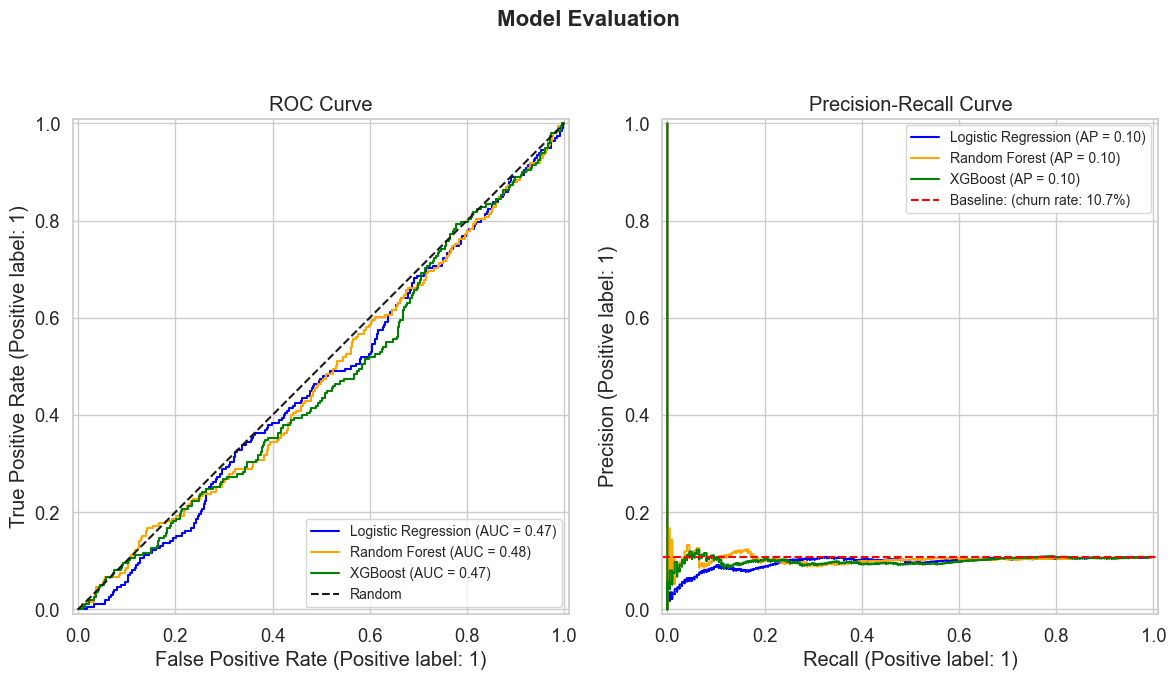

In [122]:

colors = ["blue", "orange", "green"]
fig, axes = plt.subplots(1, 2, figsize=(12, 7))

for (name, proba), color in zip(probas.items(), colors):
       # ROC Curve
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=axes[0], color=color)
     # Precision-Recall Curve
    PrecisionRecallDisplay.from_predictions(y_test, proba, name=name, ax=axes[1], color=color)


axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_title("ROC Curve")
axes[0].legend(loc="lower right", fontsize=10)


axes[1].axhline(y=chuned_rate, color="red", linestyle="--", label="Baseline: (churn rate: {:.1f}%)".format(chuned_rate * 100))
axes[1].set_title("Precision-Recall Curve")
axes[1].legend(loc="upper right", fontsize=10) 

plt.suptitle("Model Evaluation" , fontweight="bold", fontsize=16)
plt.tight_layout()
plt.show()

In [123]:
# Y-AXIS : Probability of churn ( between 0 and 1)
# X-AXIS = False positive rate (churned riders) and negative class (active riders) ---- 
# how many active riders are predicted as churned (false positive) and how many churned riders are correctly identified (true positive)
# Y-AXIS = True positive rate (churned riders correctly identified) and false positive rate (active riders incorrectly identified as churned)


# AUC Interpretation 
# 0.5 = Random guessing (no better than chance)(50/50 guessing)
# 1.0 = Perfect prediction (all churned riders correctly identified, no active riders misclassified)
# 0.47 - 0.48 = Worse than random guessing (model is systematically wrong, could be due to data issues or model misspecification)


# Number line
# 0.0 ------------------ 0.5 ------------------ 1.0

# Precision Interpretation 
# 0.11 = baseline guessing (churn rate) (11% of predicted churned riders are actually churned)
# no matter the threshold, if the model is just guessing based on the overall churn rate, it will have a precision of 0.11.
# 0.20 = Model is better than baseline (20% of predicted churned riders are actually churned)
# 0.50 = Model is very good (50% of predicted churned riders are actually churned).

### STEP 3: Threshold Turning (BEST MODEL)

In [124]:
# Here we are going to save the best model, which is XGBoost in this case, to a file using joblib. 
# This allows us to reuse the trained model later without having to retrain it from scratch.

best_name = max(probs, key=lambda n: roc_auc_score(y_test, probs[n]))
best_proba = probs[best_name]

print(f"Best model: {best_name} with AUC: {roc_auc_score(y_test, best_proba):.4f}")

Best model: XGBOOST with AUC: 0.5176


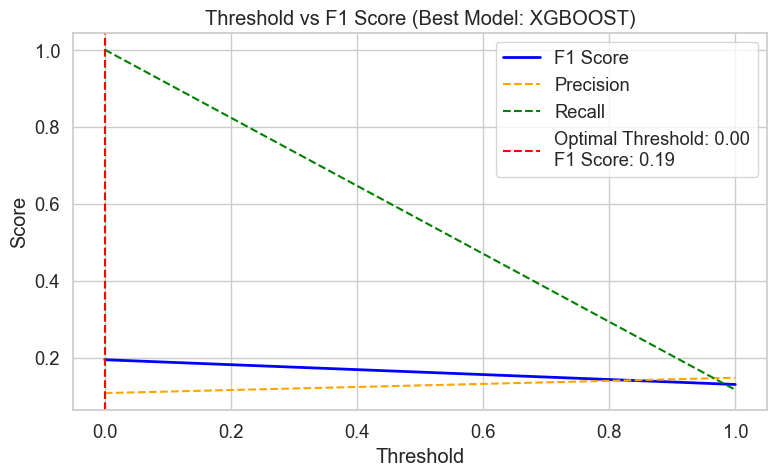

In [125]:
# default threshold is 0.5, but we can adjust it based on the business needs and get precision and recall at all thresholds.
# (e.g., if we want to catch more churned riders, we might lower the threshold to 0.3, which would increase recall but decrease precision).
# Test every threshold from 0 to 1 and calculate precision and recall at each threshold, then calculate F1 score 
# (harmonic mean of precision and recall) to find the optimal threshold that balances precision and recall for our specific use case.

precision, recall, thresholds = precision_recall_curve(y_test, best_proba)


# calculating F1 at each threshold
# why is that in an [:-1] threshold ? because the precision_recall_curve function returns an extra threshold
# at the end which is not used for prediction, so we need to exclude it when calculating F1 scores.
f1_scores = 2 * precision [:-1] * recall [:-1] / (precision [:-1] + recall [:-1])

# find the threshold with the highest F1 score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]


fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, f1_scores, color="blue", label="F1 Score", linewidth=2)
ax.plot(thresholds, precision[:-1], color="orange", label="Precision", linestyle="--")
ax.plot(thresholds, recall[:-1], color="green", label="Recall", linestyle="--")

ax.axvline(optimal_threshold, color="red", linestyle="--", label=f"Optimal Threshold: {optimal_threshold:.2f}\nF1 Score: {optimal_f1:.2f}")
ax.set(title=f"Threshold vs F1 Score (Best Model: {best_name})", xlabel="Threshold", ylabel="Score")
ax.legend()
plt.tight_layout()
plt.show()

In [126]:
# What is the probabilty cutoff that we should use to predict and decide if someone is churned or not ?
# Recall how many churner did we catch at the default threshold of 0.5 and how many we can catch at the optimal threshold based on F1 score.
# how do we determine the optimal threshold for predicting churn, and how does it compare to the default threshold of 0.5 in terms of precision, 
# recall, and F1 score?

# wide net : lower threshold (e.g., 0.3) to catch more churned riders (higher recall) but with more false positives (lower precision).
# narrow net : higher threshold (e.g., 0.7) to catch fewer churned riders (lower recall) but with fewer false positives (higher precision).

# Precision
# Low threshold = low precision (many false positives)
# High threshold = high precision (fewer false positives)

# F1 Score sweet spot is where we have a good balance between precision and recall, 
# which is often the optimal threshold for many business use cases.
# F1 score of 1 has a good balance between catching churned riders and avoiding false alarms, 
# while a F1 score of 0.2 might indicate that the model is not performing well at that threshold.

### STEP 4 - Confusion matrix

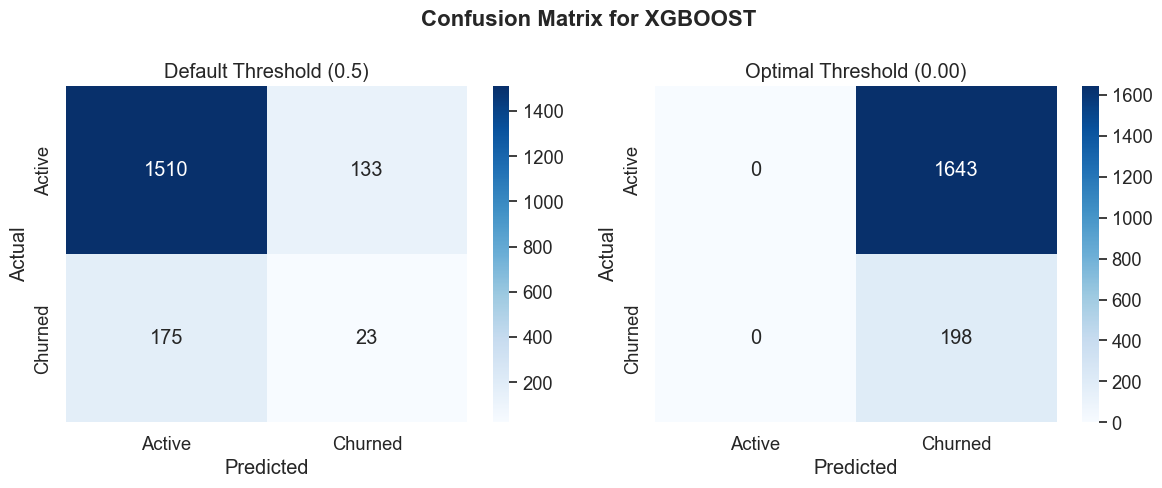

In [127]:
# CONFUSION MATRIX
# True Positives (TP): Churned riders correctly identified as churned.
# apply the most optimal threshold to get the predicted labels  

best_pred_opt = (best_proba >= optimal_threshold).astype(int)
best_prob_def = (best_proba >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, label in zip(
    axes,
    [best_prob_def, best_pred_opt],
    ["Default Threshold (0.5)", f"Optimal Threshold ({optimal_threshold:.2f})"]
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Active", "Churned"],
        yticklabels=["Active", "Churned"]
    )
    ax.set(title=label, xlabel="Predicted", ylabel="Actual")

plt.suptitle(f"Confusion Matrix for {best_name}", fontweight="bold", fontsize=16)
plt.tight_layout()
plt.show()

STEP 5 - Segment Level performance

In [128]:
# Segment Levels performance
# Does models perform work actually well for each segment ?
# Champions
# Dormant users
# loyal users
# At Risk users


test_results = pd.DataFrame({
    "user_id": df["user_id"].values,
    "y_true": y,
    "y_proba": MODELS[best_name].predict_proba(df[FEATURE_COLS].values)[:, 1],

}).merge(segment_df[["user_id", "segment"]], on="user_id", how="left")

test_results["y_pred"] = (test_results["y_proba"] >= optimal_threshold).astype(int)

# segment performance

seg_perf = (
    test_results.groupby("segment")
    .apply(lambda g: pd.Series({
        "n_riders": len(g),
        "actual_churn_pet": g["y_true"].mean() * 100,
        "predicted_churn_pet": g["y_pred"].mean() * 100,
        "avg_churn_proba": g["y_proba"].mean(),
        "auc": roc_auc_score(g["y_true"], g["y_proba"]) if g["y_true"].nunique() > 1 else np.nan  # AUC is not defined if only one class is present in the segment
    })).round(2)
)

print(seg_perf.to_string())

KeyError: 'XGBOOST'

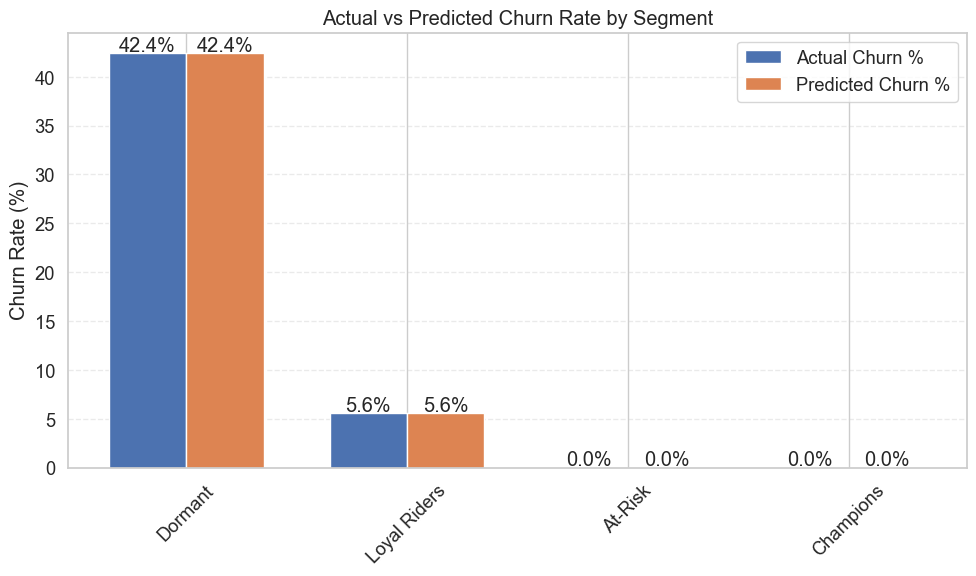

In [ ]:
# Visualize segment performance

seg_order = seg_perf["actual_churn_pet"].sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(seg_perf))
width = 0.35


ax.bar(
    x - width/2, seg_perf.loc[seg_order, "actual_churn_pet"], 
    width=width, label="Actual Churn %", edgecolor="white"
)

ax.bar(
    x + width/2, seg_perf.loc[seg_order, "predicted_churn_pet"], 
    width=width, label="Predicted Churn %", edgecolor="white"
)


for i, v in enumerate(seg_perf.loc[seg_order, "actual_churn_pet"]):
    ax.text(i - width/2, v + 0.2, f"{v:.1f}%", ha="center")

for i, v in enumerate(seg_perf.loc[seg_order, "predicted_churn_pet"]):
    ax.text(i + width/2, v + 0.2, f"{v:.1f}%", ha="center")

    #actual_color = "#1f77b4"
   # pred_color = "#ff7f0e"

ax.grid(axis="y", linestyle="--", alpha=0.4)



ax.set_xticks(x)
ax.set_xticklabels(seg_order, rotation=45)
ax.set(title="Actual vs Predicted Churn Rate by Segment", ylabel="Churn Rate (%)")
ax.legend()
plt.tight_layout()
plt.show()

### step 6 Feature Importance

- which features are actually driving churn

In [ ]:

# Feature importance for XGBoost

importances = (
    pd.Series(
        best_model.feature_importances_,
        index=FEATURE_COLS
    )
    .sort_values(ascending=False)
    .head(15)
)

# Plot feature importances
fig, ax = plt.subplots(figsize=(8, 6))

importances.sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_title("Top 15 Feature Importances (XGBoost)")
ax.set_xlabel("Importance Score")

plt.tight_layout()
plt.show()


NameError: name 'best_model' is not defined

In [ ]:
# Convert feature importances to dataframe

importance_df = pd.DataFrame({
    "feature": importances.index,
    "importance": importances.values
})

importance_df.head()
    

,feature,importance
0,engagement_score,0.035783
1,days_since_last_session,0.035716
2,rainy_ride_ratio,0.035246
3,city_encoded,0.034806
4,avg_driver_rating_received,0.034660


STEP 7 - Save the Models & Log Experiment

In [ ]:
#rows = []

for name, model in MODELS.items():
    rows.append({
        "model": name,
        "roc_auc": round(roc_auc_score(y_test, probs[name]), 4),
        "f1_def": round(f1_score(y_test, preds[name]), 4),
        "f1_opt": round(f1_score(y_test, (probs[name] >= optimal_threshold).astype(int)), 4),
        "precision_def": round(precision_score(y_test, preds[name]), 4),
        "recall_def": round(recall_score(y_test, preds[name]), 4)
    })

results_df = pd.DataFrame(rows)
results_df 

In [ ]:
top_features = importance_

In [ ]:
# Saving the artifacts

joblib.dump(best_model, os.path.join(MODEL_DIR, "churn_model.pkl"))

joblib.dump(FEATURE_COLS, os.path.join(MODEL_DIR, "feature_cols.pkl"))

joblib.dump(optimal_threshold, os.path.join(MODEL_DIR, "optimal_threshold.pkl"))

print("Model and artifacts saved successfully!")

In [ ]:
import pickle

model_dir = r"C:\Ridewise_London Project\models"

with open(os.path.join(model_dir, "churn_model.pkl"), "wb") as f:
    pickle.dump(best_model, f)